# Computational Analysis and Prediction of Ames Mutagenicity Using Molecular Descriptors

## Project overview

The Ames test is widely used to assess the mutagenic potential of chemical compounds by detecting their ability to induce genetic mutations in bacteria. Computational approaches can complement experimental toxicity testing by identifying molecular characteristics associated with mutagenicity and predicting the Ames classification of previously unseen compounds.

In this project, a dataset of experimentally characterised compounds was analysed using molecular descriptors calculated from chemical structures. Exploratory data analysis and statistical testing were used to investigate differences between mutagenic and non-mutagenic compounds. Logistic regression and random forest classifiers were then developed and evaluated for prediction of Ames mutagenicity.

### Objectives

- Calculate physicochemical and structural molecular descriptors from chemical structures.
- Compare descriptor distributions between mutagenic and non-mutagenic compounds.
- Test whether descriptor differences are statistically significant while accounting for multiple comparisons.
- Develop logistic regression and random forest models for Ames mutagenicity classification.
- Evaluate predictive performance using held-out test data and cross-validation.
- Investigate which molecular descriptors contribute most strongly to random forest predictions.


## 1. Setup and dependencies

In [63]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats

print("Environment ready!")

Environment ready!


## 2. Dataset loading and inspection

In [64]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [106]:
from pathlib import Path

possible_paths = [
    Path("data/Mutagenicity_N6512.xls"),
    Path("/content/drive/MyDrive/ames_mutagenicity_project/Mutagenicity_N6512.xls")
]

filename = next(
    (path for path in possible_paths if path.exists()),
    None
)

if filename is None:
    raise FileNotFoundError(
        "Dataset not found. Place Mutagenicity_N6512.xls "
        "inside the data/ folder."
    )

print("Dataset:", filename)

Dataset: /content/drive/MyDrive/ames_mutagenicity_project/Mutagenicity_N6512.xls


In [66]:
df = pd.read_excel(
    filename,
    engine="xlrd"
)

print(f"Rows: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:}")

Rows: 6,512
Columns: 7


In [67]:
df.head()

,CAS_NO,Source,Activity,Steroid,WDI,Canonical_Smiles,REFERENCE
0,2475-33-4,VITIC,0,-1,NaN,O=C1c2ccccc2C(=O)c3c1ccc4c3[nH]c5c6C(=O)c7cccc...,"JUDSON, PN, COOKE, PA, DOERRER, NG, GREENE, N,..."
1,820-75-7,CCRIS,1,-1,NaN,NNC(=O)CNC(=O)\C=N\#N,"MCCANN,J, CHOI,E, YAMASAKI,E AND AMES,BN, DETE..."
2,2435-76-9,CCRIS,1,-1,NaN,O=C1NC(=O)\C(=N/#N)\C=N1,"HIRAMOTO,K, KATO,T AND KIKUGAWA,K, MECHANISMS ..."
3,817-99-2,CCRIS,1,-1,NaN,NC(=O)CNC(=O)\C=N\#N,"MCCANN,J, CHOI,E, YAMASAKI,E AND AMES,BN, DETE..."
4,116539-70-9,CCRIS,1,-1,NaN,CCCCN(CC(O)C1=C\C(=N/#N)\C(=O)C=C1)N=O,"KIKUGAWA,K, KATO,T AND TAKEDA,Y, FORMATION OF ..."


In [68]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6512 entries, 0 to 6511
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CAS_NO            6512 non-null   object
 1   Source            6512 non-null   object
 2   Activity          6512 non-null   int64 
 3   Steroid           6512 non-null   int64 
 4   WDI               1416 non-null   object
 5   Canonical_Smiles  6512 non-null   object
 6   REFERENCE         6512 non-null   object
dtypes: int64(2), object(5)
memory usage: 356.3+ KB


## 3. Data preparation

In [69]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CAS_NO,6512,6512,123-01-3,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Source,6512,6,CCRIS,2542,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Activity,6512.0,NaN,NaN,NaN,0.53793,0.498598,0.0,0.0,1.0,1.0,1.0
Steroid,6512.0,NaN,NaN,NaN,-0.98188,0.18952,-1.0,-1.0,-1.0,-1.0,1.0
WDI,1416,1416,CARBENDAZ,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Canonical_Smiles,6512,6512,CCCCCCCCCCCCc1ccccc1,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
REFERENCE,6512,789,"KAZIUS, J, MCGUIRE, R AND BURSI, R. DERIVATION...",2224,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [70]:
df.isna().sum().sort_values(ascending=False)

,0
WDI,5096
Source,0
CAS_NO,0
Activity,0
Steroid,0
Canonical_Smiles,0
REFERENCE,0


In [71]:
raw_df = df.copy()

data = df.copy()

print(f"Original dataset: {raw_df.shape[0]:,} rows x {raw_df.shape[1]} columns")
print(f"Working dataset: {data.shape[0]:,} rows x {data.shape[1]} columns")

Original dataset: 6,512 rows x 7 columns
Working dataset: 6,512 rows x 7 columns


In [72]:
print("Activity distribution:")
print(data["Activity"].value_counts())

print("\nActivity proportions:")
print(data["Activity"].value_counts(normalize=True).mul(100).round(2))

Activity distribution:
Activity
1    3503
0    3009
Name: count, dtype: int64

Activity proportions:
Activity
1    53.79
0    46.21
Name: proportion, dtype: float64


In [73]:
print("WDI missing values:")
print(data["WDI"].isna().sum())

print("\nWDI missing percentage:")
print(f"{data['WDI'].isna().mean() * 100:.2f}%")

print("\nAvailable WDI values:")
print(data["WDI"].describe())

WDI missing values:
5096

WDI missing percentage:
78.26%

Available WDI values:
count          1416
unique         1416
top       CARBENDAZ
freq              1
Name: WDI, dtype: object


In [74]:
print("Total rows:", len(data))
print("Unique CAS numbers:", data["CAS_NO"].nunique())
print("Unique SMILES:", data["Canonical_Smiles"].nunique())

Total rows: 6512
Unique CAS numbers: 6512
Unique SMILES: 6512


## 4. Molecular descriptor calculations

Nine molecular descriptors were calculated from the SMILES representation of each compound using RDKit. These descriptors capture molecular size, lipophilicity, polarity, hydrogen-bonding capacity, molecular flexibility, ring composition and carbon hybridisation.

The descriptors analysed were molecular weight (MolWt), LogP, topological polar surface area (TPSA), hydrogen-bond donors (HBD), hydrogen-bond acceptors (HBA), rotatable bonds, total ring count, aromatic ring count and fraction of sp³-hybridised carbons (FractionCSP3).


In [75]:
!pip -q install rdkit

In [107]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit import RDLogger

RDLogger.DisableLog("rdApp.error")


In [108]:
data["Mol"] = data["Canonical_Smiles"].apply(Chem.MolFromSmiles)

invalid = data["Mol"].isna().sum()

print(f"Invalid SMILES: {invalid}")
print(f"Valid SMILES: {len(data) - invalid}")
print(f"Validity: {(1 - invalid/len(data))*100:.2f}%")

Invalid SMILES: 6
Valid SMILES: 6506
Validity: 99.91%


In [78]:
def calculate_descriptors(mol):
  if mol is None:
    return pd.Series({
        "MolWt": np.nan,
        "LogP": np.nan,
        "TPSA": np.nan,
        "HBD": np.nan,
        "HBA": np.nan,
        "RotatableBonds": np.nan,
        "RingCount": np.nan,
        "AromaticRingCount": np.nan,
        "FractionCSP3": np.nan
    })

  return pd.Series({
      "MolWt": Descriptors.MolWt(mol),
      "LogP": Crippen.MolLogP(mol),
      "TPSA": rdMolDescriptors.CalcTPSA(mol),
      "HBD": Lipinski.NumHDonors(mol),
      "HBA": Lipinski.NumHAcceptors(mol),
      "RotatableBonds": Lipinski.NumRotatableBonds(mol),
      "RingCount": Lipinski.RingCount(mol),
      "AromaticRingCount": Lipinski.NumAromaticRings(mol),
      "FractionCSP3": Lipinski.FractionCSP3(mol)
  })

In [79]:
descriptor_df = data["Mol"].apply(calculate_descriptors)

data = pd.concat([data, descriptor_df], axis=1)

data.head()

,CAS_NO,Source,Activity,Steroid,WDI,Canonical_Smiles,REFERENCE,Mol,MolWt,LogP,TPSA,HBD,HBA,RotatableBonds,RingCount,AromaticRingCount,FractionCSP3
0,2475-33-4,VITIC,0,-1,NaN,O=C1c2ccccc2C(=O)c3c1ccc4c3[nH]c5c6C(=O)c7cccc...,"JUDSON, PN, COOKE, PA, DOERRER, NG, GREENE, N,...",<rdkit.Chem.rdchem.Mol object at 0x7962adea6570>,646.614,6.3494,134.0,2.0,6.0,0.0,11.0,11.0,0.0
1,820-75-7,CCRIS,1,-1,NaN,NNC(=O)CNC(=O)\C=N\#N,"MCCANN,J, CHOI,E, YAMASAKI,E AND AMES,BN, DETE...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2435-76-9,CCRIS,1,-1,NaN,O=C1NC(=O)\C(=N/#N)\C=N1,"HIRAMOTO,K, KATO,T AND KIKUGAWA,K, MECHANISMS ...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,817-99-2,CCRIS,1,-1,NaN,NC(=O)CNC(=O)\C=N\#N,"MCCANN,J, CHOI,E, YAMASAKI,E AND AMES,BN, DETE...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,116539-70-9,CCRIS,1,-1,NaN,CCCCN(CC(O)C1=C\C(=N/#N)\C(=O)C=C1)N=O,"KIKUGAWA,K, KATO,T AND TAKEDA,Y, FORMATION OF ...",None,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [80]:
clean_data = data.dropna(subset=["Mol"]).copy()

print("Original number of compounds:", len(data))
print("Valid compounds:", len(clean_data))
print("Removed invalid structures:", len(data) - len(clean_data))

Original number of compounds: 6512
Valid compounds: 6506
Removed invalid structures: 6


In [81]:
print(clean_data.columns.tolist())

['CAS_NO', 'Source', 'Activity', 'Steroid', 'WDI', 'Canonical_Smiles', 'REFERENCE', 'Mol', 'MolWt', 'LogP', 'TPSA', 'HBD', 'HBA', 'RotatableBonds', 'RingCount', 'AromaticRingCount', 'FractionCSP3']


In [82]:
print(clean_data["Activity"].value_counts(dropna=False))

Activity
1    3497
0    3009
Name: count, dtype: int64


In [83]:
descriptor_cols = [
    "MolWt",
    "LogP",
    "TPSA",
    "HBD",
    "HBA",
    "RotatableBonds",
    "RingCount",
    "AromaticRingCount",
    "FractionCSP3"
]

print(clean_data[descriptor_cols].isna().sum())

MolWt                0
LogP                 0
TPSA                 0
HBD                  0
HBA                  0
RotatableBonds       0
RingCount            0
AromaticRingCount    0
FractionCSP3         0
dtype: int64


## 5. Exploratory data analysis

The processed dataset was characterised before modelling. Class balance was examined and molecular descriptor distributions were compared between Ames-positive and Ames-negative compounds. Spearman correlation analysis was used to examine relationships between descriptors and identify potentially correlated molecular properties.


In [84]:
analysis_data = clean_data.dropna(
    subset=descriptor_cols + ["Activity"]
).copy()

analysis_data["Activity"] = analysis_data["Activity"].astype(int)

print("Compounds available for analysis:", len(analysis_data))
print()
print("Activity classes:")
print(analysis_data["Activity"].value_counts())

Compounds available for analysis: 6506

Activity classes:
Activity
1    3497
0    3009
Name: count, dtype: int64


In [85]:
analysis_data["Mutagenicity"] = analysis_data["Activity"].map({
    0: "Non-mutagenic",
    1: "Mutagenic"
})

analysis_data[["Activity", "Mutagenicity"]].head()

,Activity,Mutagenicity
0,0,Non-mutagenic
7,0,Non-mutagenic
8,0,Non-mutagenic
9,1,Mutagenic
10,0,Non-mutagenic


In [86]:
summary_stats = analysis_data.groupby("Mutagenicity")[descriptor_cols].agg(
    ["mean", "median", "std"]
)

summary_stats

MolWt                          LogP                     \
                     mean   median         std     mean   median       std   
Mutagenicity                                                                 
Mutagenic      245.610617  237.306  113.171816  2.64641  2.54322  1.888116   
Non-mutagenic  249.980077  219.096  156.045329  2.43690  2.30344  2.225281   

                    TPSA                         HBD  ... RotatableBonds  \
                    mean median        std      mean  ...            std   
Mutagenicity                                          ...                  
Mutagenic      58.554387  52.04  49.029560  0.985988  ...       2.975613   
Non-mutagenic  54.978960  43.37  56.968561  1.223330  ...       4.431887   

              RingCount                  AromaticRingCount                   \
                   mean median       std              mean median       std   
Mutagenicity                                                                  
Mutagenic      2.389191    2.0  1.653762          1.877323    2.0  1.435530   
Non-mutagenic  1.763709    1.0  1.589840          1.201396    1.0  1.195898   

              FractionCSP3                      
                      mean    median       std  
Mutagenicity                                    
Mutagenic         0.268717  0.142857  0.305073  
Non-mutagenic     0.395650  0.307692  0.339671  

[2 rows x 27 columns]

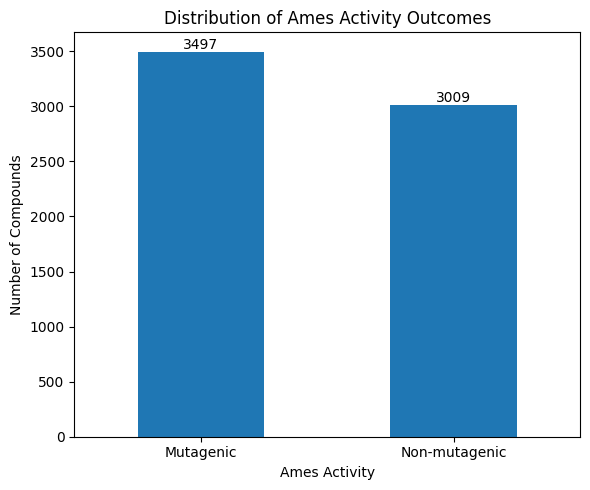

In [87]:
class_counts = analysis_data["Mutagenicity"].value_counts()

plt.figure(figsize=(6, 5))

ax = class_counts.plot(kind="bar")

plt.title("Distribution of Ames Activity Outcomes")
plt.xlabel("Ames Activity")
plt.ylabel("Number of Compounds")
plt.xticks(rotation=0)

# Add counts above bars
for container in ax.containers:
    ax.bar_label(container)

plt.tight_layout()
plt.savefig(
    "ames_class_distribution.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

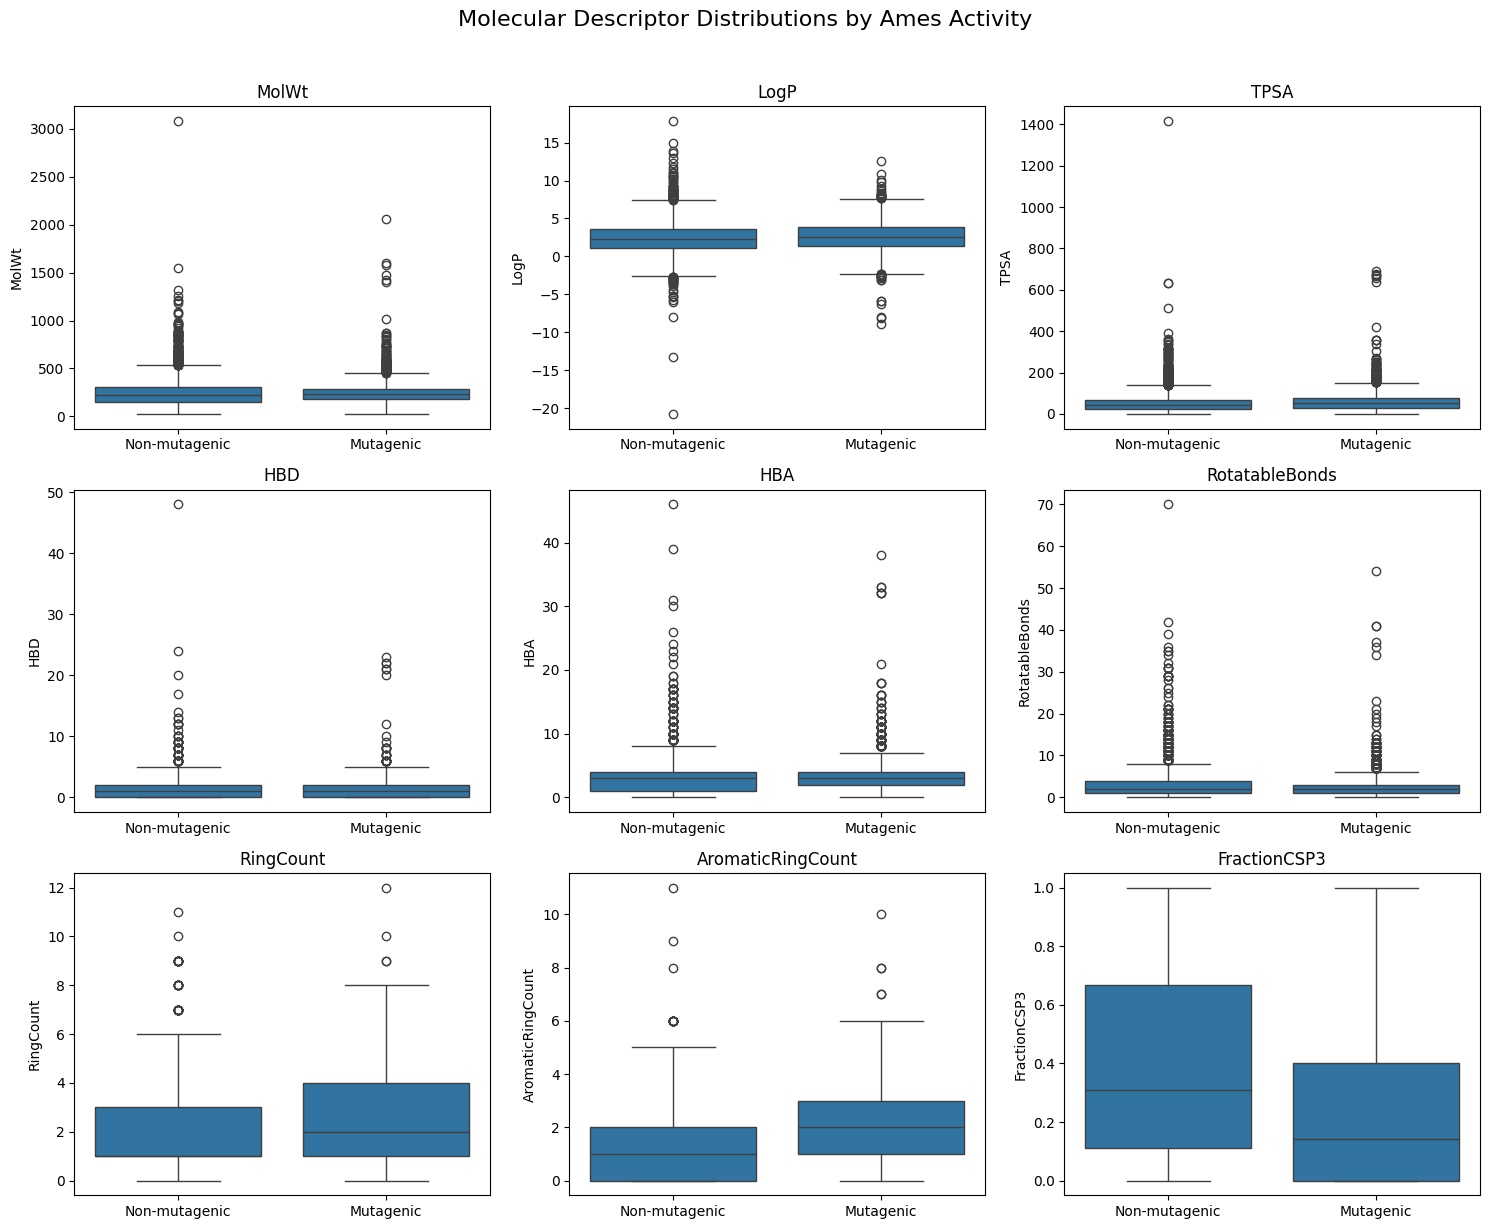

In [88]:
fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()

for i, descriptor in enumerate(descriptor_cols):
    sns.boxplot(
        data=analysis_data,
        x="Mutagenicity",
        y=descriptor,
        ax=axes[i]
    )

    axes[i].set_title(descriptor)
    axes[i].set_xlabel("")

plt.suptitle(
    "Molecular Descriptor Distributions by Ames Activity",
    fontsize=16,
    y=1.02
)

plt.tight_layout()

plt.savefig(
    "descriptor_distributions.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


In [89]:
from scipy.stats import mannwhitneyu
import pandas as pd
import numpy as np

results = []

for descriptor in descriptor_cols:
    mut = analysis_data.loc[
        analysis_data["Activity"] == 1, descriptor
    ]

    nonmut = analysis_data.loc[
        analysis_data["Activity"] == 0, descriptor
    ]

    stat, p = mannwhitneyu(
        mut,
        nonmut,
        alternative="two-sided"
    )

    # Rank-biserial correlation as effect size
    n1 = len(mut)
    n0 = len(nonmut)
    effect = (2 * stat) / (n1 * n0) - 1

    results.append({
        "Descriptor": descriptor,
        "Mutagen_Median": mut.median(),
        "NonMutagen_Median": nonmut.median(),
        "P_value": p,
        "Effect_size": effect
    })

stats_results = pd.DataFrame(results)

stats_results["Significant"] = (
    stats_results["P_value"] < 0.05
)

stats_results.sort_values(
    "P_value"
)

,Descriptor,Mutagen_Median,NonMutagen_Median,P_value,Effect_size,Significant
7,AromaticRingCount,2.000000,1.000000,1.144083e-87,0.277216,True
6,RingCount,2.000000,1.000000,3.484107e-62,0.234501,True
8,FractionCSP3,0.142857,0.307692,3.465337e-56,-0.225245,True
5,RotatableBonds,2.000000,2.000000,9.652573e-15,-0.109637,True
2,TPSA,52.040000,43.370000,2.523163e-12,0.100503,True
4,HBA,3.000000,3.000000,4.915410e-10,0.088166,True
1,LogP,2.543220,2.303440,2.848585e-07,0.073699,True
3,HBD,1.000000,1.000000,5.265219e-07,-0.067804,True
0,MolWt,237.306000,219.096000,2.992134e-05,0.059928,True


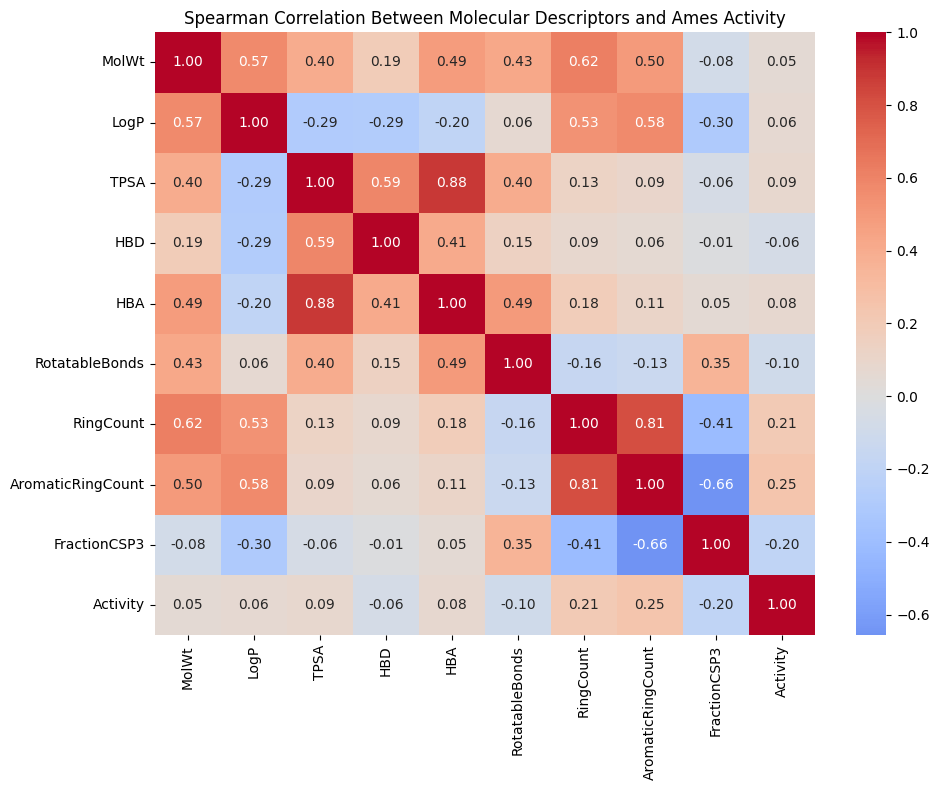

In [90]:
correlation_matrix = analysis_data[
    descriptor_cols + ["Activity"]
].corr(method="spearman")

plt.figure(figsize=(10, 8))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title(
    "Spearman Correlation Between Molecular Descriptors and Ames Activity"
)

plt.tight_layout()

plt.savefig(
    "descriptor_correlation_heatmap.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 6. Machine-learning dataset preparation

The molecular descriptors were used as predictor variables and Ames activity as the binary target. Data were divided into 80% training and 20% testing sets using stratified sampling to preserve the class distribution. A fixed random seed was used to improve reproducibility.


In [91]:
from sklearn.model_selection import train_test_split

X = analysis_data[descriptor_cols]
y = analysis_data["Activity"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training compounds:", len(X_train))
print("Testing compounds:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training compounds: 5204
Testing compounds: 1302

Training class distribution:
Activity
1    2797
0    2407
Name: count, dtype: int64

Testing class distribution:
Activity
1    700
0    602
Name: count, dtype: int64


## 7. Logistic regression baseline model

Logistic regression was used as an interpretable linear baseline classifier. Predictor variables were standardised before model fitting because the molecular descriptors are measured on different numerical scales.

In [92]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    roc_auc_score
)

logistic_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        max_iter=1000,
        random_state=42
    ))
])

logistic_model.fit(X_train, y_train)

logistic_predictions = logistic_model.predict(X_test)
logistic_probabilities = logistic_model.predict_proba(X_test)[:, 1]

print(
    "Accuracy:",
    round(accuracy_score(y_test, logistic_predictions), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, logistic_probabilities), 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        logistic_predictions,
        target_names=["Non-mutagenic", "Mutagenic"]
    )
)

Accuracy: 0.659
ROC-AUC: 0.701

Classification Report:
               precision    recall  f1-score   support

Non-mutagenic       0.65      0.58      0.61       602
    Mutagenic       0.67      0.73      0.70       700

     accuracy                           0.66      1302
    macro avg       0.66      0.65      0.65      1302
 weighted avg       0.66      0.66      0.66      1302



## 8. Random forest model

A random forest classifier was trained to determine whether a nonlinear model could improve prediction from the same molecular descriptors. Class weighting was used to account for the modest difference in class frequencies.

In [93]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=500,
    random_state=42,
    n_jobs=-1,
    class_weight="balanced"
)

rf_model.fit(X_train, y_train)

rf_predictions = rf_model.predict(X_test)
rf_probabilities = rf_model.predict_proba(X_test)[:, 1]

print(
    "Accuracy:",
    round(accuracy_score(y_test, rf_predictions), 3)
)

print(
    "ROC-AUC:",
    round(roc_auc_score(y_test, rf_probabilities), 3)
)

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        rf_predictions,
        target_names=["Non-mutagenic", "Mutagenic"]
    )
)

Accuracy: 0.767
ROC-AUC: 0.834

Classification Report:
               precision    recall  f1-score   support

Non-mutagenic       0.77      0.71      0.74       602
    Mutagenic       0.77      0.81      0.79       700

     accuracy                           0.77      1302
    macro avg       0.77      0.76      0.76      1302
 weighted avg       0.77      0.77      0.77      1302



## 9. Model comparison and evaluation

Model performance was evaluated on the held-out test set using accuracy, precision, recall, F1-score and receiver operating characteristic area under the curve (ROC-AUC). ROC curves and confusion matrices were used to visualise discrimination and classification errors.


In [94]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_score(y_test, logistic_predictions),
        accuracy_score(y_test, rf_predictions)
    ],
    "ROC_AUC": [
        roc_auc_score(y_test, logistic_probabilities),
        roc_auc_score(y_test, rf_probabilities)
    ]
})

model_comparison

,Model,Accuracy,ROC_AUC
0,Logistic Regression,0.658986,0.700984
1,Random Forest,0.766513,0.834467


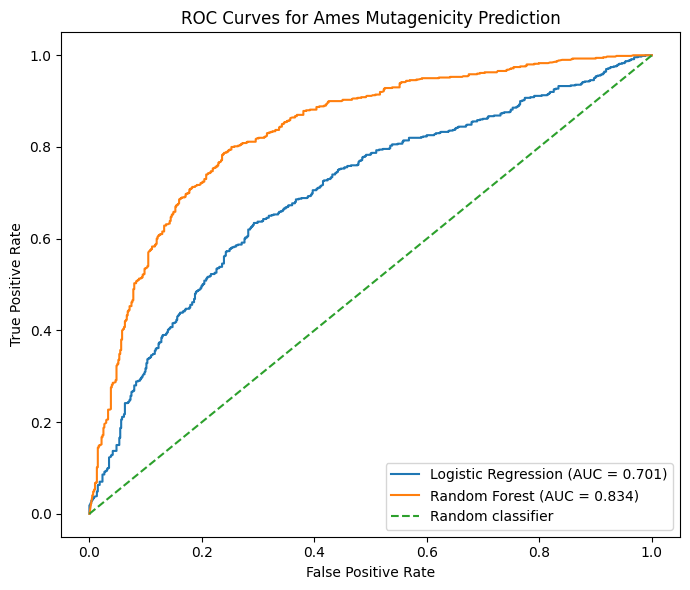

In [95]:
from sklearn.metrics import roc_curve

log_auc = roc_auc_score(
    y_test,
    logistic_probabilities
)

rf_auc = roc_auc_score(
    y_test,
    rf_probabilities
)

log_fpr, log_tpr, _ = roc_curve(
    y_test,
    logistic_probabilities
)

rf_fpr, rf_tpr, _ = roc_curve(
    y_test,
    rf_probabilities
)

plt.figure(figsize=(7, 6))

plt.plot(
    log_fpr,
    log_tpr,
    label=f"Logistic Regression (AUC = {log_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    "--",
    label="Random classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Ames Mutagenicity Prediction")
plt.legend()

plt.tight_layout()

plt.savefig(
    "roc_curve_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

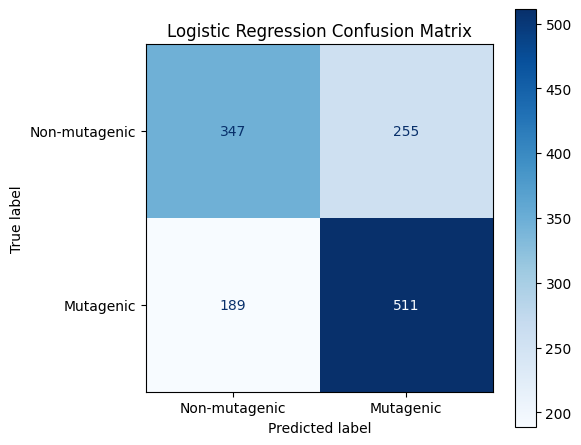

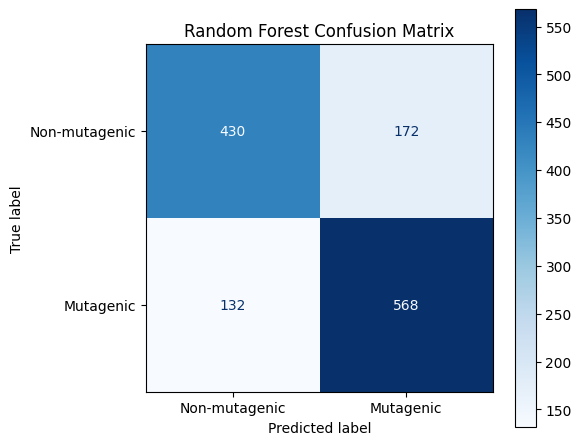

In [96]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic regression confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Non-mutagenic", "Mutagenic"],
    cmap="Blues",
    ax=ax
)

plt.title("Logistic Regression Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "logistic_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# Random forest confusion matrix
fig, ax = plt.subplots(figsize=(6, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Non-mutagenic", "Mutagenic"],
    cmap="Blues",
    ax=ax
)

plt.title("Random Forest Confusion Matrix")
plt.tight_layout()

plt.savefig(
    "random_forest_confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 10. Model interpretation

Feature importance was examined to investigate which molecular descriptors contributed most strongly to random forest predictions. Permutation importance was additionally calculated on the held-out test set by measuring the decrease in ROC-AUC when each descriptor was randomly shuffled.

In [97]:
feature_importance = pd.DataFrame({
    "Descriptor": descriptor_cols,
    "Importance": rf_model.feature_importances_
}).sort_values(
    "Importance",
    ascending=False
)

feature_importance

,Descriptor,Importance
1,LogP,0.196452
0,MolWt,0.188164
2,TPSA,0.162949
8,FractionCSP3,0.126121
5,RotatableBonds,0.083397
4,HBA,0.065454
6,RingCount,0.062205
7,AromaticRingCount,0.059170
3,HBD,0.056088


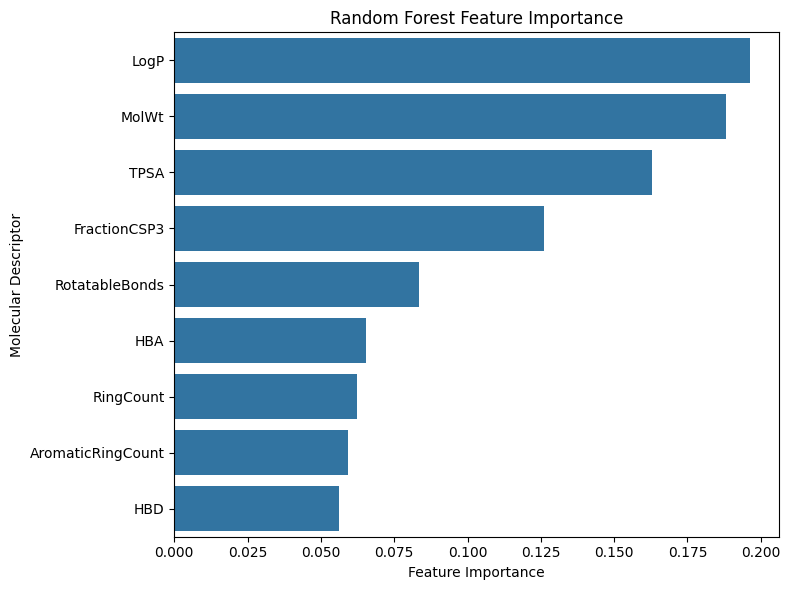

In [98]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Descriptor"
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Feature Importance")
plt.ylabel("Molecular Descriptor")

plt.tight_layout()
plt.show()

## 11. Cross-validation

Five-fold stratified cross-validation was performed to assess whether random forest performance was consistent across different partitions of the dataset. Accuracy, ROC-AUC and F1-score were calculated for each fold and summarised as the mean ± standard deviation.


In [99]:
from sklearn.model_selection import StratifiedKFold, cross_validate

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = cross_validate(
    rf_model,
    X,
    y,
    cv=cv,
    scoring=["accuracy", "roc_auc", "f1"],
    n_jobs=-1
)

print("5-Fold Cross-Validation Results")
print("--------------------------------")
print(
    f"Accuracy: {cv_results['test_accuracy'].mean():.3f} "
    f"± {cv_results['test_accuracy'].std():.3f}"
)
print(
    f"ROC-AUC:  {cv_results['test_roc_auc'].mean():.3f} "
    f"± {cv_results['test_roc_auc'].std():.3f}"
)
print(
    f"F1 score: {cv_results['test_f1'].mean():.3f} "
    f"± {cv_results['test_f1'].std():.3f}"
)

5-Fold Cross-Validation Results
--------------------------------
Accuracy: 0.760 ± 0.007
ROC-AUC:  0.830 ± 0.005
F1 score: 0.778 ± 0.006


In [100]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    rf_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="roc_auc",
    n_jobs=-1
)

permutation_df = pd.DataFrame({
    "Descriptor": descriptor_cols,
    "Importance": perm.importances_mean,
    "SD": perm.importances_std
}).sort_values(
    "Importance",
    ascending=False
)

permutation_df

/usr/local/lib/python3.13/dist-packages/joblib/externals/loky/process_executor.py:782: UserWarning: A worker stopped while some jobs were given to the executor. This can be caused by a too short worker timeout or by a memory leak.
  warnings.warn(


,Descriptor,Importance,SD
0,MolWt,0.086730,0.007879
2,TPSA,0.081575,0.005686
1,LogP,0.059512,0.006026
8,FractionCSP3,0.059134,0.007962
6,RingCount,0.056067,0.005714
7,AromaticRingCount,0.035065,0.006496
3,HBD,0.033124,0.005060
4,HBA,0.028846,0.003657
5,RotatableBonds,0.026545,0.005883


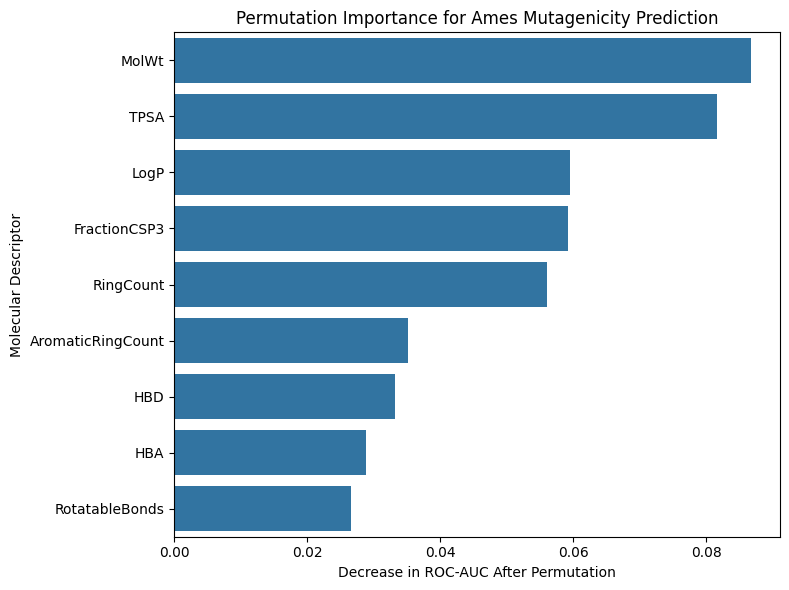

In [101]:
plt.figure(figsize=(8, 6))

sns.barplot(
    data=permutation_df,
    x="Importance",
    y="Descriptor"
)

plt.title("Permutation Importance for Ames Mutagenicity Prediction")
plt.xlabel("Decrease in ROC-AUC After Permutation")
plt.ylabel("Molecular Descriptor")

plt.tight_layout()

plt.savefig(
    "permutation_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


## 12. Summary and conclusions

## Results

The final dataset contained 6,506 compounds, including 3,497 Ames-positive and 3,009 Ames-negative compounds.

All nine molecular descriptors differed significantly between mutagenic and non-mutagenic compounds after Benjamini–Hochberg false discovery rate correction. However, effect sizes varied considerably. The largest univariate effects were observed for aromatic ring count, total ring count and FractionCSP3. Mutagenic compounds tended to contain more aromatic and total rings and showed lower sp³ character than non-mutagenic compounds.

Logistic regression provided a moderate linear baseline, achieving an accuracy of 0.659 and ROC-AUC of 0.701 on the held-out test set. The random forest classifier performed substantially better, with an accuracy of 0.767 and ROC-AUC of 0.834.

Random forest performance remained consistent under five-fold stratified cross-validation, with mean accuracy of 0.760 ± 0.007, mean ROC-AUC of 0.830 ± 0.005 and mean F1-score of 0.778 ± 0.006.

Permutation importance identified molecular weight, TPSA, LogP, FractionCSP3 and ring count as the most influential descriptors for random forest prediction.


## Discussion

The results indicate that Ames mutagenicity is associated with a combination of molecular size, polarity, lipophilicity, ring structure and carbon hybridisation. The strongest univariate associations were observed for aromatic ring count, total ring count and FractionCSP3, suggesting that more aromatic and less saturated chemical structures are more frequently associated with Ames-positive activity in this dataset.

The improvement in performance from logistic regression to random forest suggests that the relationship between these molecular descriptors and mutagenicity is not purely linear. The random forest was able to exploit nonlinear interactions between descriptors, producing substantially higher predictive performance.

The similarity between held-out test performance and five-fold cross-validation performance suggests that the random forest result is reasonably stable across different data partitions.

However, the model is based on only nine relatively simple two-dimensional molecular descriptors. It therefore does not explicitly capture detailed functional groups, substructural alerts, stereochemistry or three-dimensional molecular features that may influence mutagenicity. In addition, the use of a random train-test split means structurally related compounds may occur in both training and test sets. A scaffold-based split would provide a more stringent assessment of generalisation to novel chemical scaffolds.

Finally, Ames activity is an experimental mutagenicity endpoint and should not be interpreted as a complete measure of human toxicity or carcinogenicity.

## Conclusion

This project demonstrates that simple molecular descriptors can provide meaningful predictive information for Ames mutagenicity. A nonlinear random forest classifier substantially outperformed a linear logistic regression baseline, while statistical and feature-importance analyses identified molecular size, polarity, lipophilicity, ring structure and sp³ character as important contributors.

Overall, the analysis shows how cheminformatics and machine-learning methods can be used to investigate structure-property relationships and support computational toxicology workflows.


In [102]:
print("AMES MUTAGENICITY ANALYSIS — FINAL SUMMARY")
print("=" * 50)

print(f"\nTotal compounds analysed: {len(analysis_data)}")
print(f"Mutagenic: {(y == 1).sum()}")
print(f"Non-mutagenic: {(y == 0).sum()}")

print("\nLOGISTIC REGRESSION")
print(
    f"Accuracy: {accuracy_score(y_test, logistic_predictions):.3f}"
)
print(
    f"ROC-AUC: {roc_auc_score(y_test, logistic_probabilities):.3f}"
)

print("\nRANDOM FOREST")
print(
    f"Accuracy: {accuracy_score(y_test, rf_predictions):.3f}"
)
print(
    f"ROC-AUC: {roc_auc_score(y_test, rf_probabilities):.3f}"
)

print("\n5-FOLD RANDOM FOREST CROSS-VALIDATION")
print(
    f"Accuracy: {cv_results['test_accuracy'].mean():.3f} "
    f"± {cv_results['test_accuracy'].std():.3f}"
)
print(
    f"ROC-AUC: {cv_results['test_roc_auc'].mean():.3f} "
    f"± {cv_results['test_roc_auc'].std():.3f}"
)

print("\nLargest univariate effect sizes:")
print(
    stats_results
    .assign(abs_effect=stats_results["Effect_size"].abs())
    .sort_values("abs_effect", ascending=False)
    [["Descriptor", "Effect_size"]]
    .head(5)
    .to_string(index=False)
)

print("\nTop permutation-importance descriptors:")
print(
    permutation_df[
        ["Descriptor", "Importance"]
    ].head(5).to_string(index=False)
)

AMES MUTAGENICITY ANALYSIS — FINAL SUMMARY

Total compounds analysed: 6506
Mutagenic: 3497
Non-mutagenic: 3009

LOGISTIC REGRESSION
Accuracy: 0.659
ROC-AUC: 0.701

RANDOM FOREST
Accuracy: 0.767
ROC-AUC: 0.834

5-FOLD RANDOM FOREST CROSS-VALIDATION
Accuracy: 0.760 ± 0.007
ROC-AUC: 0.830 ± 0.005

Largest univariate effect sizes:
       Descriptor  Effect_size
AromaticRingCount     0.277216
        RingCount     0.234501
     FractionCSP3    -0.225245
   RotatableBonds    -0.109637
             TPSA     0.100503

Top permutation-importance descriptors:
  Descriptor  Importance
       MolWt    0.086730
        TPSA    0.081575
        LogP    0.059512
FractionCSP3    0.059134
   RingCount    0.056067


In [103]:
from statsmodels.stats.multitest import multipletests

stats_results["Adjusted_P_value"] = multipletests(
    stats_results["P_value"],
    method="fdr_bh"
)[1]

stats_results["Significant_FDR"] = (
    stats_results["Adjusted_P_value"] < 0.05
)

stats_results.sort_values("Adjusted_P_value")

,Descriptor,Mutagen_Median,NonMutagen_Median,P_value,Effect_size,Significant,Adjusted_P_value,Significant_FDR
7,AromaticRingCount,2.000000,1.000000,1.144083e-87,0.277216,True,1.029675e-86,True
6,RingCount,2.000000,1.000000,3.484107e-62,0.234501,True,1.567848e-61,True
8,FractionCSP3,0.142857,0.307692,3.465337e-56,-0.225245,True,1.039601e-55,True
5,RotatableBonds,2.000000,2.000000,9.652573e-15,-0.109637,True,2.171829e-14,True
2,TPSA,52.040000,43.370000,2.523163e-12,0.100503,True,4.541693e-12,True
4,HBA,3.000000,3.000000,4.915410e-10,0.088166,True,7.373115e-10,True
1,LogP,2.543220,2.303440,2.848585e-07,0.073699,True,3.662466e-07,True
3,HBD,1.000000,1.000000,5.265219e-07,-0.067804,True,5.923372e-07,True
0,MolWt,237.306000,219.096000,2.992134e-05,0.059928,True,2.992134e-05,True


In [105]:
# Export final project results

analysis_data.drop(columns=["Mol"]).to_csv(
    "ames_analysis_dataset.csv",
    index=False
)

stats_results.to_csv(
    "descriptor_statistical_tests.csv",
    index=False
)

model_comparison.to_csv(
    "model_performance.csv",
    index=False
)

feature_importance.to_csv(
    "random_forest_feature_importance.csv",
    index=False
)

permutation_df.to_csv(
    "permutation_importance.csv",
    index=False
)

print("All project result files exported successfully.")


All project result files exported successfully.
